In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [2]:
!pip install -q transformers datasets scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import torch
import io
import random
import os
import time
from PIL import Image, ImageFilter, ImageEnhance
from transformers import CLIPModel, CLIPProcessor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from tqdm import tqdm
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True).to(device)
model.eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_embedding(output):
    if isinstance(output, torch.Tensor):
        return output
    elif hasattr(output, "image_embeds"):
        return output.image_embeds
    elif hasattr(output, "pooler_output"):
        return output.pooler_output
    else:
        raise ValueError(f"Unexpected output type: {type(output)}")

print("Setup complete.")

c:\Users\arunk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 3717.39it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Setup complete.


In [4]:
def jpeg_compress(img, quality):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def gaussian_blur(img, sigma):
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def resize_degrade(img, scale):
    w, h = img.size
    small = img.resize((max(1, int(w*scale)), max(1, int(h*scale))))
    return small.resize((w, h))

def gaussian_noise(img, sigma):
    arr = np.array(img).astype(np.float32) / 255.0
    noise = np.random.normal(0, sigma, arr.shape)
    noisy = np.clip(arr + noise, 0, 1) * 255
    return Image.fromarray(noisy.astype(np.uint8))

def color_jitter(img, factor):
    img = ImageEnhance.Brightness(img).enhance(1 + factor)
    img = ImageEnhance.Contrast(img).enhance(1 + factor)
    return img

def center_crop(img, pct):
    w, h = img.size
    new_w, new_h = int(w*pct), int(h*pct)
    left, top = (w - new_w) // 2, (h - new_h) // 2
    return img.crop((left, top, left+new_w, top+new_h)).resize((w, h))

def random_degrade(img):
    choice = random.choice(["clean", "jpeg", "blur", "resize", "noise", "jitter", "crop"])
    if choice == "clean": return img
    elif choice == "jpeg": return jpeg_compress(img, random.choice([90, 70, 50, 30]))
    elif choice == "blur": return gaussian_blur(img, random.choice([0.5, 1.0, 2.0]))
    elif choice == "resize": return resize_degrade(img, random.choice([0.5, 0.25]))
    elif choice == "noise": return gaussian_noise(img, random.choice([0.02, 0.05, 0.10]))
    elif choice == "jitter": return color_jitter(img, 0.2)
    elif choice == "crop": return center_crop(img, 0.8)

transforms_to_test = {
    "clean": lambda img: img,
    "jpeg_q90": lambda img: jpeg_compress(img, 90),
    "jpeg_q50": lambda img: jpeg_compress(img, 50),
    "jpeg_q30": lambda img: jpeg_compress(img, 30),
    "blur_sigma1": lambda img: gaussian_blur(img, 1.0),
    "blur_sigma2": lambda img: gaussian_blur(img, 2.0),
    "resize_0.5x": lambda img: resize_degrade(img, 0.5),
    "resize_0.25x": lambda img: resize_degrade(img, 0.25),
    "noise_0.05": lambda img: gaussian_noise(img, 0.05),
    "noise_0.10": lambda img: gaussian_noise(img, 0.10),
    "color_jitter": lambda img: color_jitter(img, 0.2),
    "center_crop80": lambda img: center_crop(img, 0.8),
}

print("Transforms defined.")

Transforms defined.


In [5]:
def extract_frequency_features(img, size=32):
    gray = np.array(img.convert("L")).astype(np.float32)
    fft_shifted = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.log(np.abs(fft_shifted) + 1e-8)
    magnitude_arr = np.array(Image.fromarray(magnitude).resize((size, size)))
    normalized = (magnitude_arr - magnitude_arr.mean()) / (magnitude_arr.std() + 1e-8)
    return normalized.flatten()

print("FFT feature function defined.")

FFT feature function defined.


In [6]:
def extract_combined_embeddings(items, batch_size=32, freq_size=32, augment=False):
    all_clip, all_freq, all_labels = [], [], []

    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        raw_images = [img for img, _ in batch]
        images = [random_degrade(img) for img in raw_images] if augment else raw_images
        labels = [label for _, label in batch]

        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.get_image_features(**inputs)
        clip_emb = get_embedding(output).cpu().numpy()

        freq_emb = np.stack([extract_frequency_features(img, size=freq_size) for img in images])

        all_clip.append(clip_emb)
        all_freq.append(freq_emb)
        all_labels.extend(labels)

    clip_embeddings = np.concatenate(all_clip, axis=0)
    freq_embeddings = np.concatenate(all_freq, axis=0)
    labels = np.array(all_labels)
    combined = np.concatenate([clip_embeddings, freq_embeddings], axis=1)
    return combined, labels

print("Combined extraction function defined.")

Combined extraction function defined.


In [7]:
def collect_sid_examples(stream, n_per_class, classes=(0, 1, 2), max_size=384):
    counts = {c: 0 for c in classes}
    collected = []
    for example in stream:
        label = example["label"]
        if label in classes and counts[label] < n_per_class:
            img = example["image"].convert("RGB")
            img.thumbnail((max_size, max_size))
            binary_label = 0 if label == 0 else 1
            collected.append((img, binary_label))
            counts[label] += 1
        if all(c >= n_per_class for c in counts.values()):
            break
    return collected

sid_train_stream = load_dataset("saberzl/SID_Set", split="train", streaming=True)
sid_val_stream = load_dataset("saberzl/SID_Set", split="validation", streaming=True)

sid_train_items = collect_sid_examples(sid_train_stream, n_per_class=500)
sid_val_items = collect_sid_examples(sid_val_stream, n_per_class=200)

print("Train items:", len(sid_train_items))
print("Val items:", len(sid_val_items))

Train items: 1500
Val items: 600


In [8]:
sid_train_combined, sid_train_lbl = extract_combined_embeddings(sid_train_items, augment=False)
sid_val_combined, sid_val_lbl = extract_combined_embeddings(sid_val_items, augment=False)

print("Combined feature shape:", sid_train_combined.shape)

sid_clf_combined = LogisticRegression(max_iter=2000)
sid_clf_combined.fit(sid_train_combined, sid_train_lbl)

preds = sid_clf_combined.predict(sid_val_combined)
probs = sid_clf_combined.predict_proba(sid_val_combined)[:, 1]
print("Clean accuracy:", accuracy_score(sid_val_lbl, preds))
print("Clean ROC-AUC:", roc_auc_score(sid_val_lbl, probs))

100%|██████████| 19/19 [00:18<00:00,  1.04it/s]


Combined feature shape: (1500, 1536)
Clean accuracy: 0.91
Clean ROC-AUC: 0.9542375000000001


In [9]:
def run_robustness_test(clf, val_items, freq_size=32):
    results = {}
    for name, transform_fn in transforms_to_test.items():
        clip_list, freq_list, labels_list = [], [], []
        for i in range(0, len(val_items), 32):
            batch = val_items[i:i+32]
            images = [transform_fn(img) for img, _ in batch]
            labels = [label for _, label in batch]

            inputs = processor(images=images, return_tensors="pt").to(device)
            with torch.no_grad():
                output = model.get_image_features(**inputs)
            clip_emb = get_embedding(output).cpu().numpy()
            freq_emb = np.stack([extract_frequency_features(img, size=freq_size) for img in images])

            clip_list.append(clip_emb)
            freq_list.append(freq_emb)
            labels_list.extend(labels)

        combined = np.concatenate([
            np.concatenate(clip_list, axis=0),
            np.concatenate(freq_list, axis=0),
        ], axis=1)
        labels_arr = np.array(labels_list)

        preds = clf.predict(combined)
        probs = clf.predict_proba(combined)[:, 1]
        acc = accuracy_score(labels_arr, preds)
        auc = roc_auc_score(labels_arr, probs)
        results[name] = {"acc": acc, "auc": auc}
        print(f"{name}: acc={acc:.4f}, auc={auc:.4f}")
    return results

print("Running robustness test on clean-trained model...")
results_clean = run_robustness_test(sid_clf_combined, sid_val_items)

Running robustness test on clean-trained model...
clean: acc=0.9100, auc=0.9542
jpeg_q90: acc=0.8767, auc=0.9349
jpeg_q50: acc=0.7500, auc=0.8985
jpeg_q30: acc=0.7367, auc=0.9083
blur_sigma1: acc=0.6300, auc=0.9041
blur_sigma2: acc=0.5317, auc=0.8105
resize_0.5x: acc=0.6683, auc=0.8924
resize_0.25x: acc=0.4900, auc=0.8084
noise_0.05: acc=0.5883, auc=0.8706
noise_0.10: acc=0.4750, auc=0.8434
color_jitter: acc=0.8717, auc=0.9365
center_crop80: acc=0.6117, auc=0.8993


In [10]:
sid_train_combined_robust, sid_train_lbl_robust = extract_combined_embeddings(sid_train_items, augment=True)

train_start = time.time()
sid_clf_final = LogisticRegression(max_iter=2000)
sid_clf_final.fit(sid_train_combined_robust, sid_train_lbl_robust)
train_time = time.time() - train_start

print(f"Final model trained in {train_time:.3f}s")

print("\nRunning robustness test on FINAL (degradation-trained) model...")
results_final = run_robustness_test(sid_clf_final, sid_val_items)

100%|██████████| 47/47 [00:54<00:00,  1.16s/it]


Final model trained in 1.008s

Running robustness test on FINAL (degradation-trained) model...
clean: acc=0.8617, auc=0.9284
jpeg_q90: acc=0.8417, auc=0.9095
jpeg_q50: acc=0.8367, auc=0.9007
jpeg_q30: acc=0.8400, auc=0.9106
blur_sigma1: acc=0.8550, auc=0.9299
blur_sigma2: acc=0.8500, auc=0.9231
resize_0.5x: acc=0.8533, auc=0.9224
resize_0.25x: acc=0.8367, auc=0.9034
noise_0.05: acc=0.8267, auc=0.8912
noise_0.10: acc=0.8200, auc=0.8859
color_jitter: acc=0.8367, auc=0.9146
center_crop80: acc=0.8750, auc=0.9365


In [11]:
# Parameter count
clip_params = sum(p.numel() for p in model.parameters())
print(f"CLIP model parameters: {clip_params:,} ({clip_params/1e6:.1f}M) — well under the 2B cap")

# Inference time per image (full pipeline: CLIP + FFT)
sample_imgs = [img for img, _ in sid_val_items[:50]]

start = time.time()
for img in sample_imgs:
    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.get_image_features(**inputs)
    clip_emb = get_embedding(output).cpu().numpy()
    freq_emb = extract_frequency_features(img)
elapsed = time.time() - start

print(f"\nInference benchmark ({len(sample_imgs)} images):")
print(f"Total time: {elapsed:.2f}s")
print(f"Average time per image: {elapsed/len(sample_imgs)*1000:.1f}ms")
print(f"Throughput: {len(sample_imgs)/elapsed:.1f} images/sec")

print(f"\nClassifier training time: {train_time:.3f}s (near-instant — trains on pre-extracted features)")

if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

CLIP model parameters: 151,277,313 (151.3M) — well under the 2B cap

Inference benchmark (50 images):
Total time: 3.11s
Average time per image: 62.2ms
Throughput: 16.1 images/sec

Classifier training time: 1.008s (near-instant — trains on pre-extracted features)
GPU memory allocated: 0.61 GB


In [12]:
clean_auc = results_final["clean"]["auc"]
robust_aucs = [v["auc"] for k, v in results_final.items() if k != "clean"]
robust_avg = np.mean(robust_aucs)
final_score = 0.5 * clean_auc + 0.5 * robust_avg

print(f"Clean AUC: {clean_auc:.4f}")
print(f"Average robust AUC (11 transforms): {robust_avg:.4f}")
print(f"FINAL COMBINED SCORE (0.5×clean + 0.5×robust): {final_score:.4f}")

Clean AUC: 0.9284
Average robust AUC (11 transforms): 0.9116
FINAL COMBINED SCORE (0.5×clean + 0.5×robust): 0.9200


# PRNU feature extraction Method

In [13]:
import scipy.ndimage

def extract_prnu_features(img, size=32):
    gray = np.array(img.convert("L")).astype(np.float32)
    denoised = scipy.ndimage.median_filter(gray, size=3)
    residual = gray - denoised
    residual_arr = np.array(Image.fromarray(residual).resize((size, size)))
    normalized = (residual_arr - residual_arr.mean()) / (residual_arr.std() + 1e-8)
    return normalized.flatten()

def extract_combined_embeddings_prnu(items, batch_size=32, prnu_size=32, augment=False):
    all_clip, all_prnu, all_labels = [], [], []

    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        raw_images = [img for img, _ in batch]
        images = [random_degrade(img) for img in raw_images] if augment else raw_images
        labels = [label for _, label in batch]

        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.get_image_features(**inputs)
        clip_emb = get_embedding(output).cpu().numpy()

        prnu_emb = np.stack([extract_prnu_features(img, size=prnu_size) for img in images])

        all_clip.append(clip_emb)
        all_prnu.append(prnu_emb)
        all_labels.extend(labels)

    clip_embeddings = np.concatenate(all_clip, axis=0)
    prnu_embeddings = np.concatenate(all_prnu, axis=0)
    labels = np.array(all_labels)
    combined = np.concatenate([clip_embeddings, prnu_embeddings], axis=1)
    return combined, labels

print("PRNU functions defined.")

PRNU functions defined.


In [14]:
sid_train_prnu, sid_train_lbl_prnu = extract_combined_embeddings_prnu(sid_train_items, augment=False)
sid_val_prnu, sid_val_lbl_prnu = extract_combined_embeddings_prnu(sid_val_items, augment=False)

print("PRNU combined feature shape:", sid_train_prnu.shape)

sid_clf_prnu = LogisticRegression(max_iter=2000)
sid_clf_prnu.fit(sid_train_prnu, sid_train_lbl_prnu)

preds = sid_clf_prnu.predict(sid_val_prnu)
probs = sid_clf_prnu.predict_proba(sid_val_prnu)[:, 1]
print("PRNU clean accuracy:", accuracy_score(sid_val_lbl_prnu, preds))
print("PRNU clean ROC-AUC:", roc_auc_score(sid_val_lbl_prnu, probs))

100%|██████████| 19/19 [00:20<00:00,  1.10s/it]

PRNU combined feature shape: (1500, 1536)
PRNU clean accuracy: 0.7633333333333333
PRNU clean ROC-AUC: 0.846675


In [15]:
def run_robustness_test_prnu(clf, val_items, prnu_size=32):
    results = {}
    for name, transform_fn in transforms_to_test.items():
        clip_list, prnu_list, labels_list = [], [], []
        for i in range(0, len(val_items), 32):
            batch = val_items[i:i+32]
            images = [transform_fn(img) for img, _ in batch]
            labels = [label for _, label in batch]

            inputs = processor(images=images, return_tensors="pt").to(device)
            with torch.no_grad():
                output = model.get_image_features(**inputs)
            clip_emb = get_embedding(output).cpu().numpy()
            prnu_emb = np.stack([extract_prnu_features(img, size=prnu_size) for img in images])

            clip_list.append(clip_emb)
            prnu_list.append(prnu_emb)
            labels_list.extend(labels)

        combined = np.concatenate([
            np.concatenate(clip_list, axis=0),
            np.concatenate(prnu_list, axis=0),
        ], axis=1)
        labels_arr = np.array(labels_list)

        preds = clf.predict(combined)
        probs = clf.predict_proba(combined)[:, 1]
        acc = accuracy_score(labels_arr, preds)
        auc = roc_auc_score(labels_arr, probs)
        results[name] = {"acc": acc, "auc": auc}
        print(f"{name}: acc={acc:.4f}, auc={auc:.4f}")
    return results

print("Running robustness test on clean-trained PRNU model...")
prnu_results_clean = run_robustness_test_prnu(sid_clf_prnu, sid_val_items)

Running robustness test on clean-trained PRNU model...
clean: acc=0.7633, auc=0.8467
jpeg_q90: acc=0.7633, auc=0.8335
jpeg_q50: acc=0.7533, auc=0.8223
jpeg_q30: acc=0.7417, auc=0.8105
blur_sigma1: acc=0.7467, auc=0.8174
blur_sigma2: acc=0.7167, auc=0.7749
resize_0.5x: acc=0.7383, auc=0.8094
resize_0.25x: acc=0.7200, auc=0.7890
noise_0.05: acc=0.7617, auc=0.8085
noise_0.10: acc=0.7533, auc=0.8061
color_jitter: acc=0.7717, auc=0.8347
center_crop80: acc=0.7467, auc=0.7930


In [16]:
sid_train_prnu_robust, sid_train_lbl_prnu_robust = extract_combined_embeddings_prnu(sid_train_items, augment=True)

sid_clf_prnu_robust = LogisticRegression(max_iter=2000)
sid_clf_prnu_robust.fit(sid_train_prnu_robust, sid_train_lbl_prnu_robust)
print("Retrained PRNU model on degraded images.")

print("\nRunning robustness test on robust-trained PRNU model...")
prnu_results_robust = run_robustness_test_prnu(sid_clf_prnu_robust, sid_val_items)

100%|██████████| 47/47 [01:02<00:00,  1.33s/it]


Retrained PRNU model on degraded images.

Running robustness test on robust-trained PRNU model...
clean: acc=0.7833, auc=0.8395
jpeg_q90: acc=0.7583, auc=0.8338
jpeg_q50: acc=0.7617, auc=0.8274
jpeg_q30: acc=0.7700, auc=0.8227
blur_sigma1: acc=0.7717, auc=0.8494
blur_sigma2: acc=0.7650, auc=0.8055
resize_0.5x: acc=0.7883, auc=0.8432
resize_0.25x: acc=0.7433, auc=0.8075
noise_0.05: acc=0.7483, auc=0.8105
noise_0.10: acc=0.7500, auc=0.8262
color_jitter: acc=0.7650, auc=0.8298
center_crop80: acc=0.7383, auc=0.7944


In [17]:
# Inference time per image (full pipeline: CLIP + PRNU)
sample_imgs = [img for img, _ in sid_val_items[:50]]

start = time.time()
for img in sample_imgs:
    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.get_image_features(**inputs)
    clip_emb = get_embedding(output).cpu().numpy()
    prnu_emb = extract_prnu_features(img)
elapsed = time.time() - start

print(f"PRNU pipeline inference benchmark ({len(sample_imgs)} images):")
print(f"Total time: {elapsed:.2f}s")
print(f"Average time per image: {elapsed/len(sample_imgs)*1000:.1f}ms")
print(f"Throughput: {len(sample_imgs)/elapsed:.1f} images/sec")

train_start = time.time()
sid_clf_prnu_robust_timed = LogisticRegression(max_iter=2000)
sid_clf_prnu_robust_timed.fit(sid_train_prnu_robust, sid_train_lbl_prnu_robust)
train_time_prnu = time.time() - train_start
print(f"\nPRNU classifier training time: {train_time_prnu:.3f}s")

PRNU pipeline inference benchmark (50 images):
Total time: 3.60s
Average time per image: 72.1ms
Throughput: 13.9 images/sec

PRNU classifier training time: 0.105s


In [18]:
clean_auc_prnu = prnu_results_robust["clean"]["auc"]
robust_aucs_prnu = [v["auc"] for k, v in prnu_results_robust.items() if k != "clean"]
robust_avg_prnu = np.mean(robust_aucs_prnu)
final_score_prnu = 0.5 * clean_auc_prnu + 0.5 * robust_avg_prnu

print(f"PRNU Clean AUC: {clean_auc_prnu:.4f}")
print(f"PRNU Average robust AUC: {robust_avg_prnu:.4f}")
print(f"PRNU FINAL COMBINED SCORE: {final_score_prnu:.4f}")

PRNU Clean AUC: 0.8395
PRNU Average robust AUC: 0.8228
PRNU FINAL COMBINED SCORE: 0.8311


# Azimuthal feature extraction method

In [19]:
def extract_azimuthal_fft_features(img, n_bins=64):
    gray = np.array(img.convert("L")).astype(np.float32)
    fft_shifted = np.fft.fftshift(np.fft.fft2(gray))
    magnitude = np.log(np.abs(fft_shifted) + 1e-8)

    h, w = magnitude.shape
    center_y, center_x = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2).astype(int)

    max_r = min(center_x, center_y)
    radial_profile = np.zeros(n_bins)
    bin_edges = np.linspace(0, max_r, n_bins + 1)

    for i in range(n_bins):
        mask = (r >= bin_edges[i]) & (r < bin_edges[i+1])
        if mask.sum() > 0:
            radial_profile[i] = magnitude[mask].mean()

    return (radial_profile - radial_profile.mean()) / (radial_profile.std() + 1e-8)

def extract_combined_embeddings_azimuthal(items, n_bins=64, batch_size=32, augment=False):
    all_clip, all_freq, all_labels = [], [], []

    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        raw_images = [img for img, _ in batch]
        images = [random_degrade(img) for img in raw_images] if augment else raw_images
        labels = [label for _, label in batch]

        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.get_image_features(**inputs)
        clip_emb = get_embedding(output).cpu().numpy()

        freq_emb = np.stack([extract_azimuthal_fft_features(img, n_bins=n_bins) for img in images])

        all_clip.append(clip_emb)
        all_freq.append(freq_emb)
        all_labels.extend(labels)

    clip_embeddings = np.concatenate(all_clip, axis=0)
    freq_embeddings = np.concatenate(all_freq, axis=0)
    labels = np.array(all_labels)
    combined = np.concatenate([clip_embeddings, freq_embeddings], axis=1)
    return combined, labels

print("Azimuthal functions defined.")

Azimuthal functions defined.


In [20]:
sid_train_azi, sid_train_lbl_azi = extract_combined_embeddings_azimuthal(sid_train_items, augment=False)
sid_val_azi, sid_val_lbl_azi = extract_combined_embeddings_azimuthal(sid_val_items, augment=False)

print("Azimuthal combined feature shape:", sid_train_azi.shape)

sid_clf_azimuthal = LogisticRegression(max_iter=2000)
sid_clf_azimuthal.fit(sid_train_azi, sid_train_lbl_azi)

preds = sid_clf_azimuthal.predict(sid_val_azi)
probs = sid_clf_azimuthal.predict_proba(sid_val_azi)[:, 1]
print("Azimuthal clean accuracy:", accuracy_score(sid_val_lbl_azi, preds))
print("Azimuthal clean ROC-AUC:", roc_auc_score(sid_val_lbl_azi, probs))

100%|██████████| 19/19 [00:31<00:00,  1.64s/it]

Azimuthal combined feature shape: (1500, 576)
Azimuthal clean accuracy: 0.8883333333333333
Azimuthal clean ROC-AUC: 0.9539249999999999


In [21]:
def run_robustness_test_azimuthal(clf, val_items, n_bins=64):
    results = {}
    for name, transform_fn in transforms_to_test.items():
        clip_list, freq_list, labels_list = [], [], []
        for i in range(0, len(val_items), 32):
            batch = val_items[i:i+32]
            images = [transform_fn(img) for img, _ in batch]
            labels = [label for _, label in batch]

            inputs = processor(images=images, return_tensors="pt").to(device)
            with torch.no_grad():
                output = model.get_image_features(**inputs)
            clip_emb = get_embedding(output).cpu().numpy()
            freq_emb = np.stack([extract_azimuthal_fft_features(img, n_bins=n_bins) for img in images])

            clip_list.append(clip_emb)
            freq_list.append(freq_emb)
            labels_list.extend(labels)

        combined = np.concatenate([
            np.concatenate(clip_list, axis=0),
            np.concatenate(freq_list, axis=0),
        ], axis=1)
        labels_arr = np.array(labels_list)

        preds = clf.predict(combined)
        probs = clf.predict_proba(combined)[:, 1]
        acc = accuracy_score(labels_arr, preds)
        auc = roc_auc_score(labels_arr, probs)
        results[name] = {"acc": acc, "auc": auc}
        print(f"{name}: acc={acc:.4f}, auc={auc:.4f}")
    return results

print("Running robustness test on clean-trained azimuthal model...")
azimuthal_results_clean = run_robustness_test_azimuthal(sid_clf_azimuthal, sid_val_items)

Running robustness test on clean-trained azimuthal model...
clean: acc=0.8883, auc=0.9539
jpeg_q90: acc=0.8600, auc=0.9316
jpeg_q50: acc=0.8533, auc=0.9179
jpeg_q30: acc=0.8600, auc=0.9299
blur_sigma1: acc=0.7633, auc=0.8689
blur_sigma2: acc=0.5183, auc=0.7577
resize_0.5x: acc=0.8033, auc=0.8864
resize_0.25x: acc=0.5217, auc=0.7275
noise_0.05: acc=0.7450, auc=0.8714
noise_0.10: acc=0.6500, auc=0.8657
color_jitter: acc=0.8833, auc=0.9434
center_crop80: acc=0.8850, auc=0.9506


In [22]:
sid_train_azi_robust, sid_train_lbl_azi_robust = extract_combined_embeddings_azimuthal(sid_train_items, augment=True)

sid_clf_azimuthal_robust = LogisticRegression(max_iter=2000)
sid_clf_azimuthal_robust.fit(sid_train_azi_robust, sid_train_lbl_azi_robust)
print("Retrained azimuthal model on degraded images.")

print("\nRunning robustness test on robust-trained azimuthal model...")
azimuthal_results_robust = run_robustness_test_azimuthal(sid_clf_azimuthal_robust, sid_val_items)

100%|██████████| 47/47 [01:21<00:00,  1.74s/it]


Retrained azimuthal model on degraded images.

Running robustness test on robust-trained azimuthal model...
clean: acc=0.8617, auc=0.9236
jpeg_q90: acc=0.8400, auc=0.9038
jpeg_q50: acc=0.8367, auc=0.9023
jpeg_q30: acc=0.8567, auc=0.9262
blur_sigma1: acc=0.8467, auc=0.9165
blur_sigma2: acc=0.8583, auc=0.9216
resize_0.5x: acc=0.8467, auc=0.9110
resize_0.25x: acc=0.8617, auc=0.9164
noise_0.05: acc=0.8033, auc=0.8811
noise_0.10: acc=0.7883, auc=0.8779
color_jitter: acc=0.8700, auc=0.9177
center_crop80: acc=0.8583, auc=0.9344


In [23]:
sample_imgs = [img for img, _ in sid_val_items[:50]]

start = time.time()
for img in sample_imgs:
    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.get_image_features(**inputs)
    clip_emb = get_embedding(output).cpu().numpy()
    azi_emb = extract_azimuthal_fft_features(img)
elapsed = time.time() - start

print(f"Azimuthal pipeline inference benchmark ({len(sample_imgs)} images):")
print(f"Total time: {elapsed:.2f}s")
print(f"Average time per image: {elapsed/len(sample_imgs)*1000:.1f}ms")
print(f"Throughput: {len(sample_imgs)/elapsed:.1f} images/sec")

train_start = time.time()
sid_clf_azimuthal_robust_timed = LogisticRegression(max_iter=2000)
sid_clf_azimuthal_robust_timed.fit(sid_train_azi_robust, sid_train_lbl_azi_robust)
train_time_azi = time.time() - train_start
print(f"\nAzimuthal classifier training time: {train_time_azi:.3f}s")

Azimuthal pipeline inference benchmark (50 images):
Total time: 4.22s
Average time per image: 84.5ms
Throughput: 11.8 images/sec

Azimuthal classifier training time: 0.192s


In [24]:
clean_auc_azi = azimuthal_results_robust["clean"]["auc"]
robust_aucs_azi = [v["auc"] for k, v in azimuthal_results_robust.items() if k != "clean"]
robust_avg_azi = np.mean(robust_aucs_azi)
final_score_azi = 0.5 * clean_auc_azi + 0.5 * robust_avg_azi

print(f"Azimuthal Clean AUC: {clean_auc_azi:.4f}")
print(f"Azimuthal Average robust AUC: {robust_avg_azi:.4f}")
print(f"Azimuthal FINAL COMBINED SCORE: {final_score_azi:.4f}")

Azimuthal Clean AUC: 0.9236
Azimuthal Average robust AUC: 0.9099
Azimuthal FINAL COMBINED SCORE: 0.9167


# Contrastive training method

In [25]:
import torch.nn as nn
import torch.nn.functional as F

class ProjectionHead(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    sim_matrix = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * batch_size, device=z.device).bool()
    sim_matrix.masked_fill_(mask, -1e9)
    positive_indices = torch.cat([
        torch.arange(batch_size, 2*batch_size),
        torch.arange(0, batch_size)
    ]).to(z.device)
    return F.cross_entropy(sim_matrix, positive_indices)

projection_head = ProjectionHead().to(device)
print("Projection head defined.")

Projection head defined.


In [26]:
optimizer = torch.optim.Adam(projection_head.parameters(), lr=1e-3)
n_epochs = 5
batch_size = 16

images_only = [img for img, _ in sid_train_items]

train_start = time.time()
for epoch in range(n_epochs):
    random.shuffle(images_only)
    total_loss = 0
    n_batches = 0

    for i in tqdm(range(0, len(images_only), batch_size), desc=f"Epoch {epoch+1}/{n_epochs}"):
        batch = images_only[i:i+batch_size]
        if len(batch) < 2:
            continue

        view1 = [random_degrade(img) for img in batch]
        view2 = [random_degrade(img) for img in batch]

        inputs1 = processor(images=view1, return_tensors="pt").to(device)
        inputs2 = processor(images=view2, return_tensors="pt").to(device)

        with torch.no_grad():
            emb1 = get_embedding(model.get_image_features(**inputs1))
            emb2 = get_embedding(model.get_image_features(**inputs2))

        z1 = projection_head(emb1)
        z2 = projection_head(emb2)
        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    print(f"Epoch {epoch+1}: avg loss = {total_loss/max(n_batches,1):.4f}")

contrastive_train_time = time.time() - train_start
print(f"\nContrastive pretraining time: {contrastive_train_time:.2f}s")

Epoch 1/5: 100%|██████████| 94/94 [01:22<00:00,  1.14it/s]


Epoch 1: avg loss = 1.8722


Epoch 2/5: 100%|██████████| 94/94 [01:22<00:00,  1.15it/s]


Epoch 2: avg loss = 1.7926


Epoch 3/5: 100%|██████████| 94/94 [01:24<00:00,  1.11it/s]


Epoch 3: avg loss = 1.7677


Epoch 4/5: 100%|██████████| 94/94 [01:25<00:00,  1.09it/s]


Epoch 4: avg loss = 1.7505


Epoch 5/5: 100%|██████████| 94/94 [01:26<00:00,  1.09it/s]

Epoch 5: avg loss = 1.7405

Contrastive pretraining time: 421.14s


In [27]:
def extract_contrastive_combined(items, batch_size=32, augment=False):
    all_feat, all_labels = [], []
    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        raw_images = [img for img, _ in batch]
        images = [random_degrade(img) for img in raw_images] if augment else raw_images
        labels = [label for _, label in batch]

        inputs = processor(images=images, return_tensors="pt").to(device)
        with torch.no_grad():
            emb = get_embedding(model.get_image_features(**inputs))
            proj = projection_head(emb)
        clip_feat = proj.cpu().numpy()
        freq_feat = np.stack([extract_frequency_features(img) for img in images])

        for cf, ff, l in zip(clip_feat, freq_feat, labels):
            all_feat.append(np.concatenate([cf, ff]))
            all_labels.append(l)

    return np.array(all_feat), np.array(all_labels)

sid_train_contrastive, sid_train_lbl_contrastive = extract_contrastive_combined(sid_train_items, augment=False)
sid_val_contrastive, sid_val_lbl_contrastive = extract_contrastive_combined(sid_val_items, augment=False)

sid_clf_contrastive = LogisticRegression(max_iter=2000)
sid_clf_contrastive.fit(sid_train_contrastive, sid_train_lbl_contrastive)

preds = sid_clf_contrastive.predict(sid_val_contrastive)
probs = sid_clf_contrastive.predict_proba(sid_val_contrastive)[:, 1]
print("Contrastive clean accuracy:", accuracy_score(sid_val_lbl_contrastive, preds))
print("Contrastive clean ROC-AUC:", roc_auc_score(sid_val_lbl_contrastive, probs))

100%|██████████| 19/19 [00:18<00:00,  1.01it/s]


Contrastive clean accuracy: 0.8366666666666667
Contrastive clean ROC-AUC: 0.8896000000000001


In [28]:
def run_robustness_test_contrastive(clf, val_items):
    results = {}
    for name, transform_fn in transforms_to_test.items():
        feat_list, labels_list = [], []
        for i in range(0, len(val_items), 32):
            batch = val_items[i:i+32]
            images = [transform_fn(img) for img, _ in batch]
            labels = [label for _, label in batch]

            inputs = processor(images=images, return_tensors="pt").to(device)
            with torch.no_grad():
                emb = get_embedding(model.get_image_features(**inputs))
                proj = projection_head(emb)
            clip_feat = proj.cpu().numpy()
            freq_feat = np.stack([extract_frequency_features(img) for img in images])

            for cf, ff, l in zip(clip_feat, freq_feat, labels):
                feat_list.append(np.concatenate([cf, ff]))
                labels_list.append(l)

        feats = np.array(feat_list)
        labels_arr = np.array(labels_list)

        preds = clf.predict(feats)
        probs = clf.predict_proba(feats)[:, 1]
        acc = accuracy_score(labels_arr, preds)
        auc = roc_auc_score(labels_arr, probs)
        results[name] = {"acc": acc, "auc": auc}
        print(f"{name}: acc={acc:.4f}, auc={auc:.4f}")
    return results

print("Running robustness test on contrastive model...")
contrastive_results = run_robustness_test_contrastive(sid_clf_contrastive, sid_val_items)

Running robustness test on contrastive model...
clean: acc=0.8367, auc=0.8896
jpeg_q90: acc=0.7867, auc=0.8754
jpeg_q50: acc=0.5417, auc=0.8196
jpeg_q30: acc=0.4967, auc=0.8124
blur_sigma1: acc=0.4167, auc=0.8566
blur_sigma2: acc=0.5917, auc=0.7717
resize_0.5x: acc=0.5217, auc=0.8646
resize_0.25x: acc=0.3900, auc=0.7388
noise_0.05: acc=0.6883, auc=0.8138
noise_0.10: acc=0.6900, auc=0.7574
color_jitter: acc=0.7783, auc=0.8597
center_crop80: acc=0.3600, auc=0.7579


In [29]:
sample_imgs = [img for img, _ in sid_val_items[:50]]

start = time.time()
for img in sample_imgs:
    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        emb = get_embedding(model.get_image_features(**inputs))
        proj = projection_head(emb)
    freq_emb = extract_frequency_features(img)
elapsed = time.time() - start

print(f"Contrastive pipeline inference benchmark ({len(sample_imgs)} images):")
print(f"Average time per image: {elapsed/len(sample_imgs)*1000:.1f}ms")

proj_params = sum(p.numel() for p in projection_head.parameters())
print(f"Projection head parameters: {proj_params:,}")
print(f"Contrastive pretraining time (5 epochs): {contrastive_train_time:.2f}s  <- much higher than other methods")

clean_auc_c = contrastive_results["clean"]["auc"]
robust_avg_c = np.mean([v["auc"] for k, v in contrastive_results.items() if k != "clean"])
final_score_c = 0.5 * clean_auc_c + 0.5 * robust_avg_c
print(f"\nContrastive FINAL COMBINED SCORE: {final_score_c:.4f}")

Contrastive pipeline inference benchmark (50 images):
Average time per image: 52.0ms
Projection head parameters: 164,224
Contrastive pretraining time (5 epochs): 421.14s  <- much higher than other methods

Contrastive FINAL COMBINED SCORE: 0.8506


# Four way comparison

In [30]:
comparison_table = {
    "CLIP+FFT (final)": {
        "clean_auc": results_final["clean"]["auc"],
        "combined_score": 0.5 * results_final["clean"]["auc"] + 0.5 * np.mean([v["auc"] for k,v in results_final.items() if k != "clean"]),
    },
    "CLIP+PRNU": {
        "clean_auc": prnu_results_robust["clean"]["auc"],
        "combined_score": final_score_prnu,
    },
    "CLIP+Azimuthal": {
        "clean_auc": azimuthal_results_robust["clean"]["auc"],
        "combined_score": final_score_azi,
    },
    "CLIP+Contrastive": {
        "clean_auc": clean_auc_c,
        "combined_score": final_score_c,
    },
}

for name, stats in comparison_table.items():
    print(f"{name}: clean_auc={stats['clean_auc']:.4f}, combined_score={stats['combined_score']:.4f}")

CLIP+FFT (final): clean_auc=0.9284, combined_score=0.9200
CLIP+PRNU: clean_auc=0.8395, combined_score=0.8311
CLIP+Azimuthal: clean_auc=0.9236, combined_score=0.9167
CLIP+Contrastive: clean_auc=0.8896, combined_score=0.8506


In [31]:
import joblib
joblib.dump(sid_clf_final, "final_classifier.joblib")
print("Model saved.")

Model saved.


In [32]:
import json

final_results_summary = {
    "final_model": "CLIP+FFT (single-scale, size=32), degradation-consistent trained",
    "clean_auc": results_final["clean"]["auc"],
    "robustness_table": results_final,
    "comparison": {
        "CLIP+PRNU": final_score_prnu,
        "CLIP+Azimuthal": final_score_azi,
        "CLIP+Contrastive": final_score_c,
    }
}

with open("results_summary.json", "w") as f:
    json.dump(final_results_summary, f, indent=2)

print("Results saved to results_summary.json")

Results saved to results_summary.json


C:\Users\arunk\AppData\Local\Temp\ipykernel_9220\1671634992.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15)


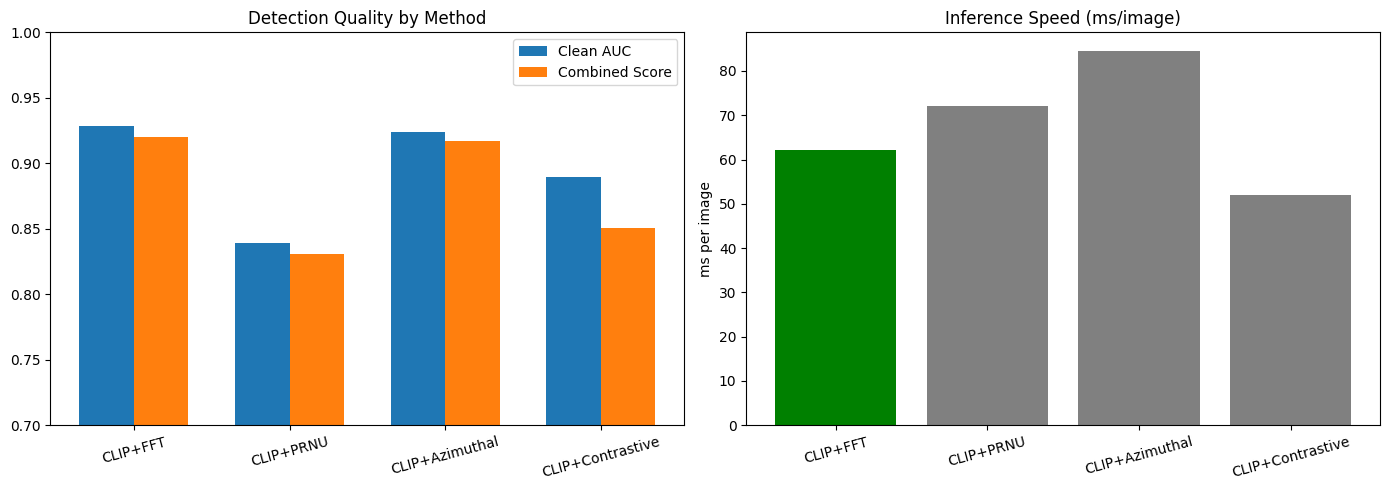

Saved to method_comparison.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["CLIP+FFT", "CLIP+PRNU", "CLIP+Azimuthal", "CLIP+Contrastive"]
clean_auc = [0.9284, 0.8395, 0.9236, 0.8896]
combined_score = [0.9200, 0.8311, 0.9167, 0.8506]
inference_ms = [62.2, 72.1, 84.5, 52.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(methods))
width = 0.35

axes[0].bar(x - width/2, clean_auc, width, label='Clean AUC')
axes[0].bar(x + width/2, combined_score, width, label='Combined Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('Detection Quality by Method')
axes[0].legend()
#axes[0].axhline(y=combined_score[0], color='green', linestyle='--', alpha=0.3)

axes[1].bar(methods, inference_ms, color=['green' if m == "CLIP+FFT" else 'gray' for m in methods])
axes[1].set_xticklabels(methods, rotation=15)
axes[1].set_title('Inference Speed (ms/image)')
axes[1].set_ylabel('ms per image')

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150)
plt.show()
print("Saved to method_comparison.png")

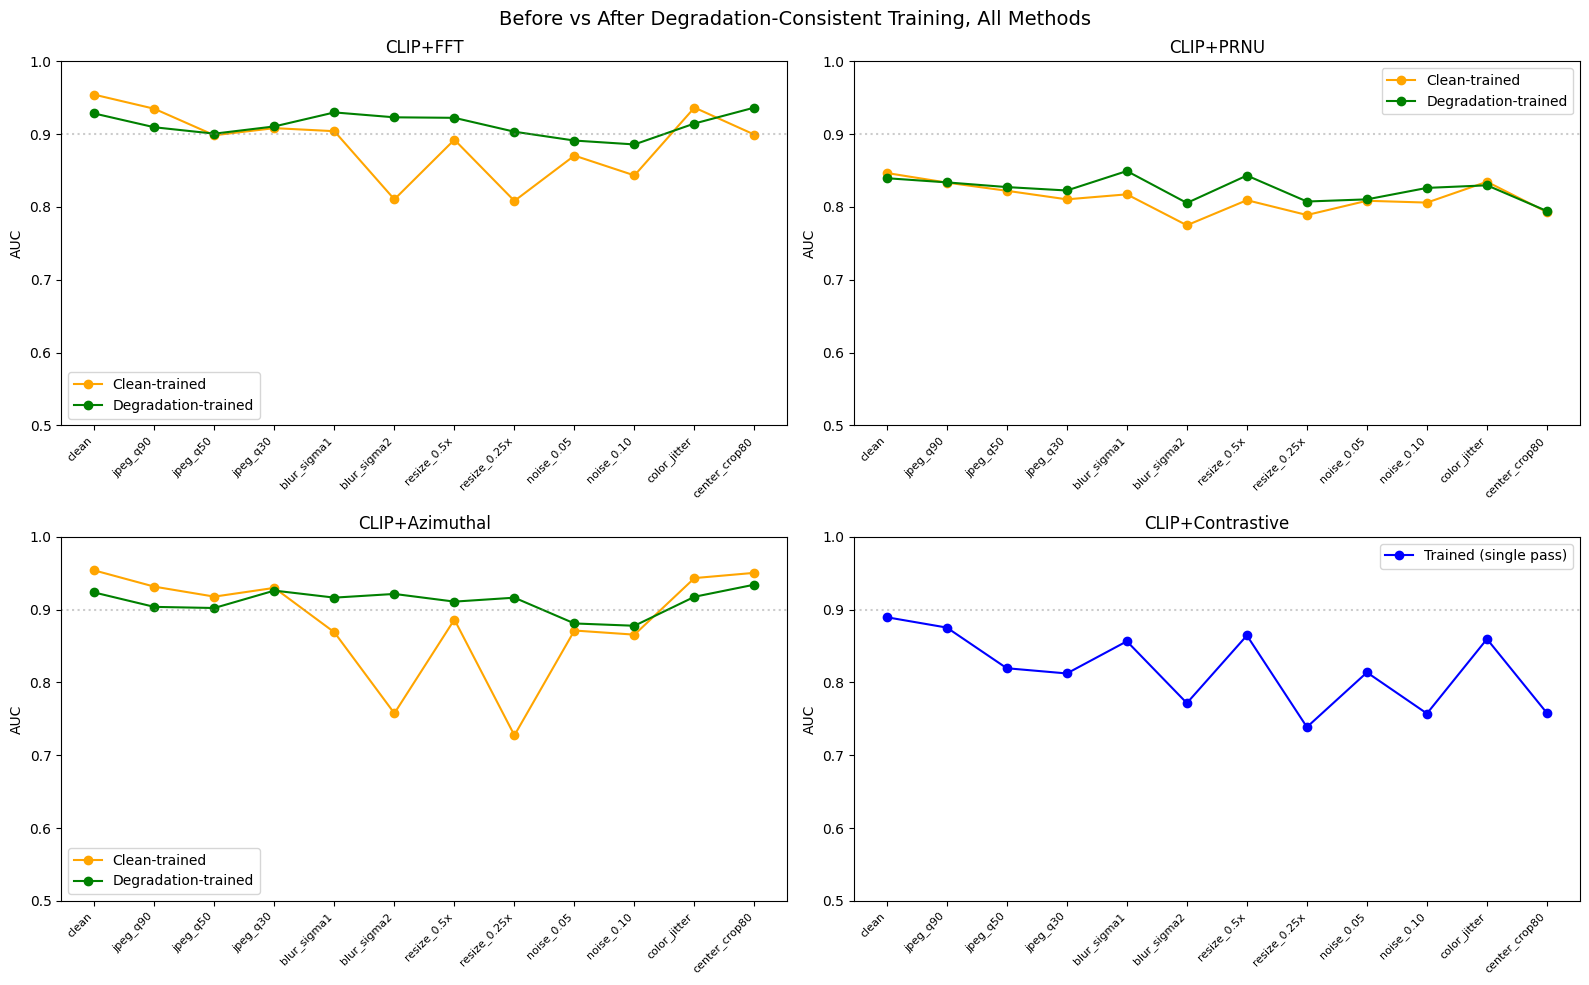

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

transforms = list(results_final.keys())
x = range(len(transforms))

# CLIP+FFT
axes[0,0].plot(x, [results_clean[t]["auc"] for t in transforms], marker='o', label='Clean-trained', color='orange')
axes[0,0].plot(x, [results_final[t]["auc"] for t in transforms], marker='o', label='Degradation-trained', color='green')
axes[0,0].set_title('CLIP+FFT')
axes[0,0].legend()

# CLIP+PRNU
axes[0,1].plot(x, [prnu_results_clean[t]["auc"] for t in transforms], marker='o', label='Clean-trained', color='orange')
axes[0,1].plot(x, [prnu_results_robust[t]["auc"] for t in transforms], marker='o', label='Degradation-trained', color='green')
axes[0,1].set_title('CLIP+PRNU')
axes[0,1].legend()

# CLIP+Azimuthal
axes[1,0].plot(x, [azimuthal_results_clean[t]["auc"] for t in transforms], marker='o', label='Clean-trained', color='orange')
axes[1,0].plot(x, [azimuthal_results_robust[t]["auc"] for t in transforms], marker='o', label='Degradation-trained', color='green')
axes[1,0].set_title('CLIP+Azimuthal')
axes[1,0].legend()

# CLIP+Contrastive (only one result set was run — plot it alone)
axes[1,1].plot(x, [contrastive_results[t]["auc"] for t in transforms], marker='o', label='Trained (single pass)', color='blue')
axes[1,1].set_title('CLIP+Contrastive')
axes[1,1].legend()

for ax in axes.flat:
    ax.set_xticks(x)
    ax.set_xticklabels(transforms, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUC')
    ax.set_ylim(0.5, 1.0)
    ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.4)

plt.suptitle('Before vs After Degradation-Consistent Training, All Methods', fontsize=14)
plt.tight_layout()
plt.savefig('all_methods_before_after.png', dpi=150)
plt.show()

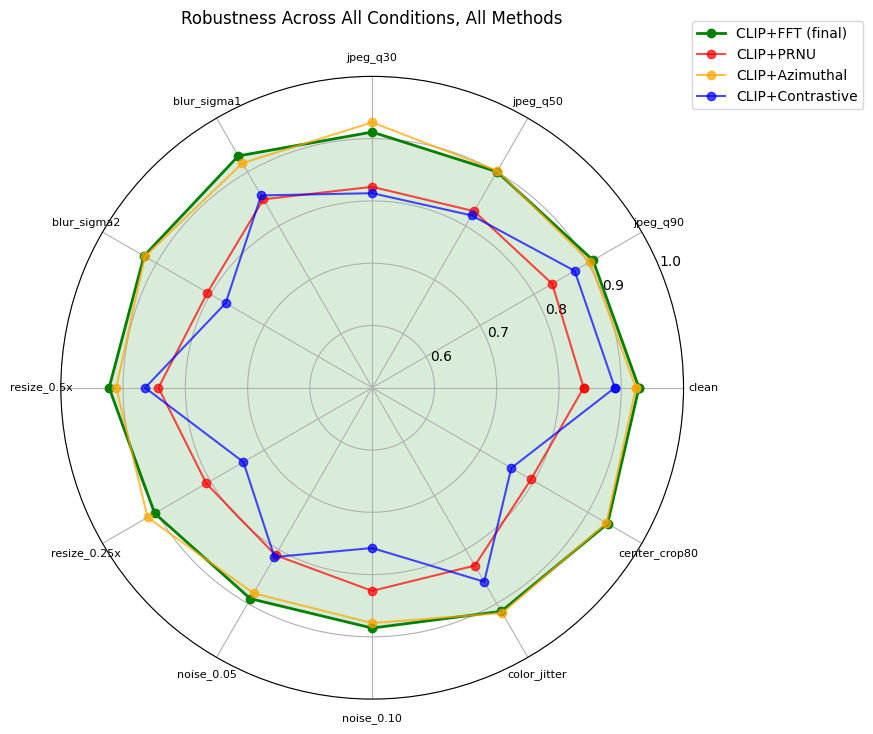

In [39]:
import numpy as np
import matplotlib.pyplot as plt

categories = list(results_final.keys())
n = len(categories)

fft_scores = [results_final[c]["auc"] for c in categories]
prnu_scores = [prnu_results_robust[c]["auc"] for c in categories]
azi_scores = [azimuthal_results_robust[c]["auc"] for c in categories]
contrastive_scores = [contrastive_results[c]["auc"] for c in categories]

angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fft_scores += fft_scores[:1]
prnu_scores += prnu_scores[:1]
azi_scores += azi_scores[:1]
contrastive_scores += contrastive_scores[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

ax.plot(angles, fft_scores, 'o-', linewidth=2, label='CLIP+FFT (final)', color='green')
ax.fill(angles, fft_scores, alpha=0.15, color='green')

ax.plot(angles, prnu_scores, 'o-', linewidth=1.5, label='CLIP+PRNU', color='red', alpha=0.7)
ax.plot(angles, azi_scores, 'o-', linewidth=1.5, label='CLIP+Azimuthal', color='orange', alpha=0.7)
ax.plot(angles, contrastive_scores, 'o-', linewidth=1.5, label='CLIP+Contrastive', color='blue', alpha=0.7)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=8)
ax.set_ylim(0.5, 1.0)
ax.set_title("Robustness Across All Conditions, All Methods", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_all_methods.png', dpi=150)
plt.show()

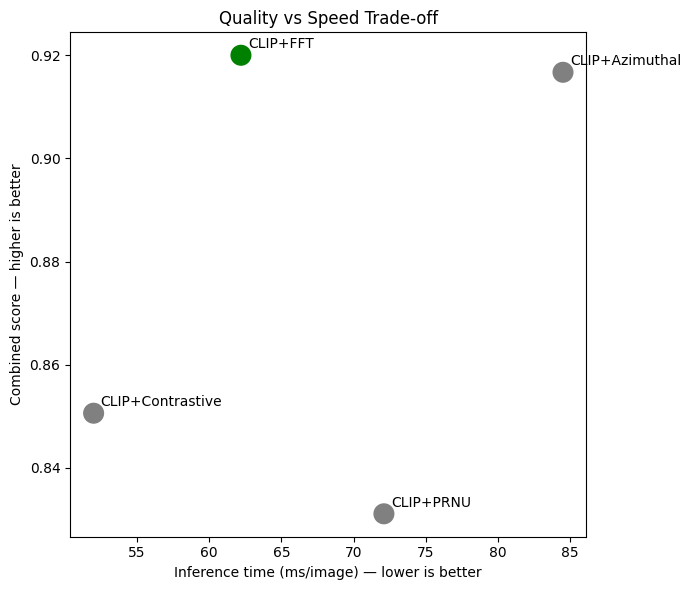

In [37]:
methods = ["CLIP+FFT", "CLIP+PRNU", "CLIP+Azimuthal", "CLIP+Contrastive"]
combined_scores = [0.9200, 0.8311, 0.9167, 0.8506]
inference_ms = [62.2, 72.1, 84.5, 52.0]

fig, ax = plt.subplots(figsize=(7,6))
colors = ['green', 'gray', 'gray', 'gray']
ax.scatter(inference_ms, combined_scores, s=200, c=colors)
for i, m in enumerate(methods):
    ax.annotate(m, (inference_ms[i], combined_scores[i]), xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Inference time (ms/image) — lower is better')
ax.set_ylabel('Combined score — higher is better')
ax.set_title('Quality vs Speed Trade-off')
plt.tight_layout()
plt.savefig('quality_vs_speed.png', dpi=150)
plt.show()